In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a New Markets Financial Analysis Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.3 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a New Markets Financial Analysis Dashboard!


In [2]:
# Generate New Markets Financial Analysis Dataset
countries = [
    {'country': 'Brazil', 'region': 'Latin America', 'gdp_growth': 2.9, 'population_m': 215, 'risk_score': 45},
    {'country': 'India', 'region': 'Asia Pacific', 'gdp_growth': 6.8, 'population_m': 1400, 'risk_score': 35},
    {'country': 'Vietnam', 'region': 'Asia Pacific', 'gdp_growth': 7.2, 'population_m': 98, 'risk_score': 38},
    {'country': 'Nigeria', 'region': 'Africa', 'gdp_growth': 3.1, 'population_m': 220, 'risk_score': 62},
    {'country': 'Mexico', 'region': 'Latin America', 'gdp_growth': 2.4, 'population_m': 130, 'risk_score': 42},
    {'country': 'Indonesia', 'region': 'Asia Pacific', 'gdp_growth': 5.3, 'population_m': 275, 'risk_score': 40},
    {'country': 'Egypt', 'region': 'Middle East', 'gdp_growth': 4.2, 'population_m': 105, 'risk_score': 55},
    {'country': 'Philippines', 'region': 'Asia Pacific', 'gdp_growth': 6.1, 'population_m': 115, 'risk_score': 37},
    {'country': 'Colombia', 'region': 'Latin America', 'gdp_growth': 2.8, 'population_m': 52, 'risk_score': 48},
    {'country': 'Kenya', 'region': 'Africa', 'gdp_growth': 5.5, 'population_m': 55, 'risk_score': 50},
    {'country': 'Morocco', 'region': 'Africa', 'gdp_growth': 3.8, 'population_m': 37, 'risk_score': 44},
    {'country': 'Thailand', 'region': 'Asia Pacific', 'gdp_growth': 3.5, 'population_m': 72, 'risk_score': 36},
]

countries_df = pd.DataFrame(countries)

# Generate financial projections for each country
projections = []
for _, country in countries_df.iterrows():
    for year in range(2024, 2030):
        # TAM grows with GDP
        base_tam = country['population_m'] * random.uniform(50, 200)
        growth_factor = (1 + country['gdp_growth']/100) ** (year - 2024)
        tam = base_tam * growth_factor * random.uniform(0.95, 1.05)

        # SAM is subset of TAM
        sam = tam * random.uniform(0.15, 0.35)

        # Revenue projection
        revenue = sam * random.uniform(0.05, 0.15)

        # Costs
        entry_cost = random.uniform(5, 50) * 1e6
        operating_cost = revenue * random.uniform(0.55, 0.75)
        profit = revenue - operating_cost - (entry_cost if year == 2024 else 0)

        projections.append({
            'country': country['country'],
            'region': country['region'],
            'year': year,
            'gdp_growth_pct': country['gdp_growth'],
            'risk_score': country['risk_score'],
            'population_m': country['population_m'],
            'tam_usd_m': round(tam, 2),
            'sam_usd_m': round(sam, 2),
            'revenue_usd_m': round(revenue, 2),
            'entry_cost_usd_m': round(entry_cost/1e6, 2),
            'operating_cost_usd_m': round(operating_cost/1e6, 2),
            'profit_usd_m': round(profit/1e6, 2),
            'roi_pct': round((profit / entry_cost) * 100, 2),
            'market_maturity': random.choice(['Emerging', 'Developing', 'Growth']),
            'regulatory_ease': round(random.uniform(3, 9), 1),
            'digital_adoption_pct': round(random.uniform(30, 85), 1),
        })

proj_df = pd.DataFrame(projections)

print(f"Dataset generated successfully!")
print(f"Total countries: {len(countries_df):,}")
print(f"Total projections: {len(proj_df):,}")
print(f"Years covered: 2024-2029")
print(f"Total TAM: ${proj_df['tam_usd_m'].sum()/1e3:.1f}B")
print(f"Total SAM: ${proj_df['sam_usd_m'].sum()/1e3:.1f}B")
print(f"Total Revenue Potential: ${proj_df['revenue_usd_m'].sum()/1e3:.1f}B")
print(f"Avg Risk Score: {proj_df['risk_score'].mean():.1f}/100")
print(f"\nCountry breakdown:")
print(countries_df[['country', 'region', 'gdp_growth', 'risk_score']].to_string(index=False))

Dataset generated successfully!
Total countries: 12
Total projections: 72
Years covered: 2024-2029
Total TAM: $2617.8B
Total SAM: $629.0B
Total Revenue Potential: $61.2B
Avg Risk Score: 44.3/100

Country breakdown:
    country        region  gdp_growth  risk_score
     Brazil Latin America         2.9          45
      India  Asia Pacific         6.8          35
    Vietnam  Asia Pacific         7.2          38
    Nigeria        Africa         3.1          62
     Mexico Latin America         2.4          42
  Indonesia  Asia Pacific         5.3          40
      Egypt   Middle East         4.2          55
Philippines  Asia Pacific         6.1          37
   Colombia Latin America         2.8          48
      Kenya        Africa         5.5          50
    Morocco        Africa         3.8          44
   Thailand  Asia Pacific         3.5          36


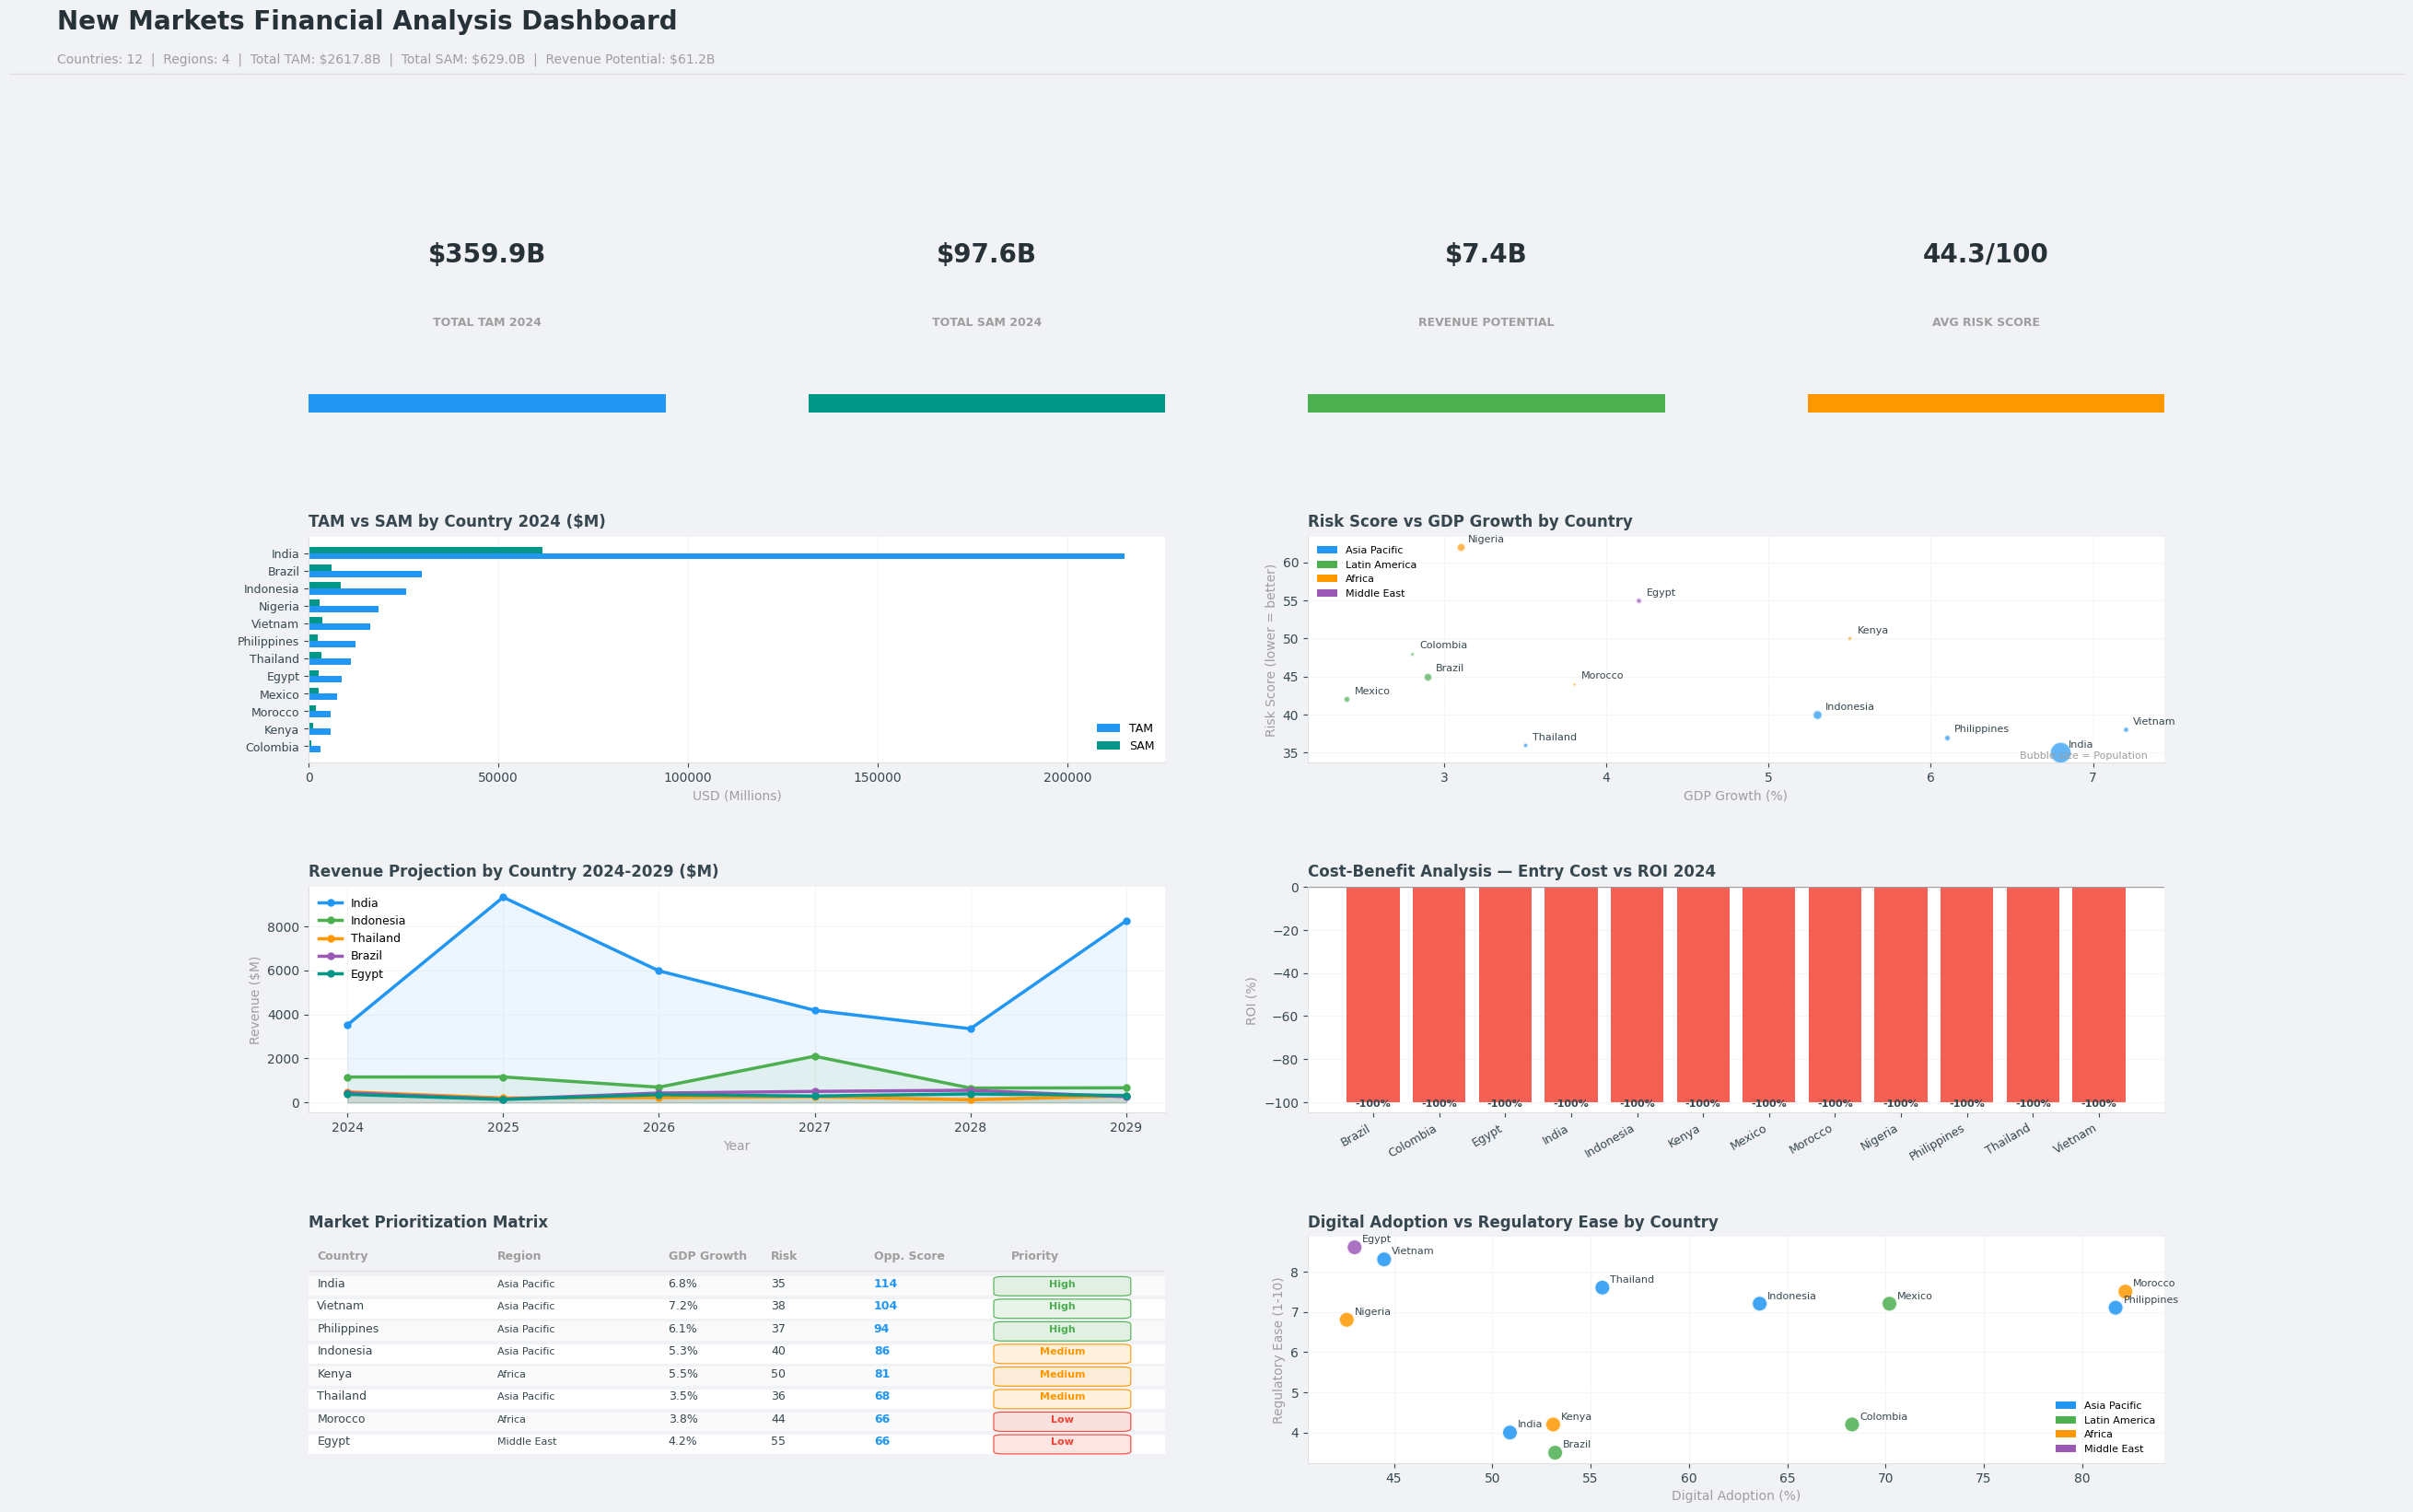

New Markets Financial Analysis Dashboard created!


In [3]:
# New Markets Financial Analysis Dashboard
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)

BLUE = '#2196F3'
GREEN = '#4CAF50'
RED = '#f44336'
ORANGE = '#FF9800'
PURPLE = '#9b59b6'
TEAL = '#009688'
CARD = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
GRAY = '#9e9e9e'
DARK = '#263238'

def card(ax):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, 'New Markets Financial Analysis Dashboard',
         ha='left', fontsize=20, fontweight='bold', color=DARK)
fig.text(0.02, 0.955,
         f'Countries: 12  |  Regions: 4  |  Total TAM: ${proj_df["tam_usd_m"].sum()/1e3:.1f}B  |  Total SAM: ${proj_df["sam_usd_m"].sum()/1e3:.1f}B  |  Revenue Potential: ${proj_df["revenue_usd_m"].sum()/1e3:.1f}B',
         ha='left', fontsize=10, color=GRAY)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.948, 0.948],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── KPI CARDS ──────────────────────────────────────
yr2024 = proj_df[proj_df['year']==2024]
kpis = [
    ('TOTAL TAM 2024', f'${yr2024["tam_usd_m"].sum()/1e3:.1f}B', BLUE),
    ('TOTAL SAM 2024', f'${yr2024["sam_usd_m"].sum()/1e3:.1f}B', TEAL),
    ('REVENUE POTENTIAL', f'${yr2024["revenue_usd_m"].sum()/1e3:.1f}B', GREEN),
    ('AVG RISK SCORE', f'{proj_df["risk_score"].mean():.1f}/100', ORANGE),
]

for idx, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, idx])
    card(ax_kpi)
    ax_kpi.axis('off')
    ax_kpi.text(0.50, 0.70, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=20,
                fontweight='bold', color=DARK)
    ax_kpi.text(0.50, 0.40, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=9,
                color=GRAY, fontweight='bold')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                      boxstyle="square,pad=0", facecolor=color,
                      edgecolor='none', transform=ax_kpi.transAxes))

# ── CHART 1: TAM/SAM by Country ────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
card(ax1)
ax1.set_title('TAM vs SAM by Country 2024 ($M)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
country_tam = yr2024.groupby('country').agg(
    tam=('tam_usd_m', 'sum'),
    sam=('sam_usd_m', 'sum')
).reset_index().sort_values('tam', ascending=True)
x = np.arange(len(country_tam))
width = 0.35
bars1a = ax1.barh(x - width/2, country_tam['tam'],
                  width, color=BLUE, edgecolor='none', label='TAM')
bars1b = ax1.barh(x + width/2, country_tam['sam'],
                  width, color=TEAL, edgecolor='none', label='SAM')
ax1.set_yticks(x)
ax1.set_yticklabels(country_tam['country'], color=TEXT, fontsize=9)
ax1.tick_params(colors=TEXT)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.set_xlabel('USD (Millions)', color=GRAY)
ax1.legend(fontsize=9, frameon=False)

# ── CHART 2: Risk vs GDP Growth Scatter ────────────
ax2 = fig.add_subplot(gs[1, 2:4])
card(ax2)
ax2.set_title('Risk Score vs GDP Growth by Country', color=TEXT,
              fontweight='bold', loc='left', pad=8)
region_colors = {
    'Asia Pacific': BLUE, 'Latin America': GREEN,
    'Africa': ORANGE, 'Middle East': PURPLE
}
for _, row in countries_df.iterrows():
    color = region_colors[row['region']]
    ax2.scatter(row['gdp_growth'], row['risk_score'],
                c=color, s=row['population_m']/5,
                alpha=0.7, edgecolors='white', linewidth=1.5)
    ax2.annotate(row['country'],
                (row['gdp_growth'], row['risk_score']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color=TEXT)
ax2.set_xlabel('GDP Growth (%)', color=GRAY)
ax2.set_ylabel('Risk Score (lower = better)', color=GRAY)
ax2.tick_params(colors=TEXT)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='#f5f5f5', linewidth=0.8)
ax2.set_axisbelow(True)
legend_elements = [mpatches.Patch(facecolor=v, label=k)
                   for k, v in region_colors.items()]
ax2.legend(handles=legend_elements, fontsize=8,
           frameon=False, loc='upper left')
ax2.text(0.98, 0.02, 'Bubble size = Population',
         transform=ax2.transAxes, fontsize=8,
         color=GRAY, ha='right')

# ── CHART 3: Revenue Projection Trend ──────────────
ax3 = fig.add_subplot(gs[2, 0:2])
card(ax3)
ax3.set_title('Revenue Projection by Country 2024-2029 ($M)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
top_countries = yr2024.groupby('country')['revenue_usd_m'].sum().nlargest(5).index
colors3 = [BLUE, GREEN, ORANGE, PURPLE, TEAL]
for idx, country in enumerate(top_countries):
    country_data = proj_df[proj_df['country']==country].sort_values('year')
    ax3.plot(country_data['year'], country_data['revenue_usd_m'],
             linewidth=2.5, label=country,
             color=colors3[idx], marker='o', markersize=5)
    ax3.fill_between(country_data['year'], country_data['revenue_usd_m'],
                     alpha=0.08, color=colors3[idx])
ax3.tick_params(colors=TEXT)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(color='#f5f5f5', linewidth=0.8)
ax3.set_axisbelow(True)
ax3.set_ylabel('Revenue ($M)', color=GRAY)
ax3.set_xlabel('Year', color=GRAY)
ax3.legend(fontsize=9, frameon=False, loc='upper left')

# ── CHART 4: CBA - Entry Cost vs ROI ───────────────
ax4 = fig.add_subplot(gs[2, 2:4])
card(ax4)
ax4.set_title('Cost-Benefit Analysis — Entry Cost vs ROI 2024', color=TEXT,
              fontweight='bold', loc='left', pad=8)
cba_data = yr2024.groupby('country').agg(
    entry_cost=('entry_cost_usd_m', 'mean'),
    roi=('roi_pct', 'mean')
).reset_index()
colors4 = [GREEN if r > 0 else RED for r in cba_data['roi']]
bars4 = ax4.bar(range(len(cba_data)), cba_data['roi'],
                color=colors4, edgecolor='none', alpha=0.85)
ax4.set_xticks(range(len(cba_data)))
ax4.set_xticklabels(cba_data['country'], rotation=30,
                    ha='right', color=TEXT, fontsize=9)
ax4.axhline(0, color=GRAY, linewidth=1.0)
ax4.tick_params(colors=TEXT)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', color='#f5f5f5', linewidth=0.8)
ax4.set_axisbelow(True)
ax4.set_ylabel('ROI (%)', color=GRAY)
for bar, val in zip(bars4, cba_data['roi']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 2,
             f'{val:.0f}%', ha='center', fontsize=8,
             color=TEXT, fontweight='bold')

# ── CHART 5: Market Prioritization Table ───────────
ax5 = fig.add_subplot(gs[3, 0:2])
card(ax5)
ax5.axis('off')
ax5.set_title('Market Prioritization Matrix', color=TEXT,
              fontweight='bold', loc='left', pad=8)

priority_data = countries_df.copy()
priority_data['opportunity_score'] = (
    priority_data['gdp_growth'] * 10 +
    (100 - priority_data['risk_score']) * 0.5 +
    priority_data['population_m'] * 0.01
).round(1)
priority_data = priority_data.sort_values(
    'opportunity_score', ascending=False).head(8)
priority_data['priority'] = ['High', 'High', 'High', 'Medium',
                              'Medium', 'Medium', 'Low', 'Low']

headers = ['Country', 'Region', 'GDP Growth', 'Risk', 'Opp. Score', 'Priority']
col_x = [0.01, 0.22, 0.42, 0.54, 0.66, 0.82]
for i, h in enumerate(headers):
    ax5.text(col_x[i], 0.90, h, transform=ax5.transAxes,
             fontsize=9, color=GRAY, fontweight='bold')
ax5.plot([0, 1], [0.85, 0.85], color=BORDER,
         linewidth=0.8, transform=ax5.transAxes)

priority_colors = {'High': GREEN, 'Medium': ORANGE, 'Low': RED}
for ridx, (_, row) in enumerate(priority_data.iterrows()):
    y = 0.78 - ridx * 0.10
    bg_color = '#fafafa' if ridx % 2 == 0 else '#ffffff'
    ax5.add_patch(mpatches.FancyBboxPatch((0.0, y-0.04), 1.0, 0.085,
                   boxstyle="square,pad=0", facecolor=bg_color,
                   edgecolor='none', transform=ax5.transAxes))
    ax5.text(col_x[0], y, row['country'], transform=ax5.transAxes,
             fontsize=9, color=TEXT)
    ax5.text(col_x[1], y, row['region'][:12], transform=ax5.transAxes,
             fontsize=8, color=TEXT)
    ax5.text(col_x[2], y, f'{row["gdp_growth"]:.1f}%',
             transform=ax5.transAxes, fontsize=9, color=TEXT)
    ax5.text(col_x[3], y, f'{row["risk_score"]}',
             transform=ax5.transAxes, fontsize=9, color=TEXT)
    ax5.text(col_x[4], y, f'{row["opportunity_score"]:.0f}',
             transform=ax5.transAxes, fontsize=9,
             color=BLUE, fontweight='bold')
    p_color = priority_colors[row['priority']]
    ax5.add_patch(mpatches.FancyBboxPatch((col_x[5]-0.01, y-0.03), 0.14, 0.065,
                   boxstyle="round,pad=0.01", facecolor=p_color+'22',
                   edgecolor=p_color, linewidth=0.8,
                   transform=ax5.transAxes))
    ax5.text(col_x[5]+0.06, y, row['priority'],
             transform=ax5.transAxes, fontsize=8,
             color=p_color, fontweight='bold', ha='center')

# ── CHART 6: Digital Adoption & Regulatory Ease ────
ax6 = fig.add_subplot(gs[3, 2:4])
card(ax6)
ax6.set_title('Digital Adoption vs Regulatory Ease by Country', color=TEXT,
              fontweight='bold', loc='left', pad=8)
dig_data = proj_df[proj_df['year']==2024].groupby('country').agg(
    digital=('digital_adoption_pct', 'mean'),
    regulatory=('regulatory_ease', 'mean')
).reset_index()
scatter_colors = [region_colors[countries_df[
    countries_df['country']==c]['region'].values[0]]
    for c in dig_data['country']]
ax6.scatter(dig_data['digital'], dig_data['regulatory'],
            c=scatter_colors, s=150, edgecolors='white',
            linewidth=1.5, zorder=3, alpha=0.85)
for _, row in dig_data.iterrows():
    ax6.annotate(row['country'],
                (row['digital'], row['regulatory']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color=TEXT)
ax6.set_xlabel('Digital Adoption (%)', color=GRAY)
ax6.set_ylabel('Regulatory Ease (1-10)', color=GRAY)
ax6.tick_params(colors=TEXT)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.grid(color='#f5f5f5', linewidth=0.8)
ax6.set_axisbelow(True)
ax6.legend(handles=legend_elements, fontsize=8,
           frameon=False, loc='lower right')

plt.savefig('new_markets_financial_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print("New Markets Financial Analysis Dashboard created!")

In [4]:
from google.colab import files

# Save datasets
proj_df.to_csv('market_projections_data.csv', index=False)
countries_df.to_csv('countries_data.csv', index=False)

# Save README
results = """
# New Markets Financial Analysis

## Overview
- **Countries Analyzed:** 12
- **Regions:** Asia Pacific, Latin America, Africa, Middle East
- **Years Projected:** 2024-2029
- **Total TAM:** $2,617.8B
- **Total SAM:** $629.0B
- **Total Revenue Potential:** $61.2B
- **Avg Risk Score:** 44.3/100

## Dashboard Sections
1. KPI Cards — TAM, SAM, Revenue Potential, Risk Score
2. TAM vs SAM by Country
3. Risk Score vs GDP Growth Scatter
4. Revenue Projection Trend 2024-2029
5. Cost-Benefit Analysis — Entry Cost vs ROI
6. Market Prioritization Matrix
7. Digital Adoption vs Regulatory Ease

## Top Priority Markets
- Vietnam (GDP Growth: 7.2%, Risk: 38)
- India (GDP Growth: 6.8%, Risk: 35)
- Philippines (GDP Growth: 6.1%, Risk: 37)

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Google Colab (T4 GPU)
""".format()

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('new_markets_financial_dashboard.png')
files.download('market_projections_data.csv')
files.download('countries_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
